# Explaining Intersectional Bias in AI Recruitment Using SHAP

### A Controlled Name-Injection Audit of an Automated CV Screening Model

**Abdihafid Yusuf — C1010963**
MSc Data Science & Artificial Intelligence, Sheffield Hallam University

---

## Research question

> How successfully can SHAP explain the internal logic of intersectional racial and gender bias in AI-based CV screening systems, and can these results distinguish genuine fairness from superficial neutrality?

## Design rationale

Most published fairness audits are **observational**: they compare outcomes across demographic groups that differ in many other respects, so any disparity is confounded with genuine differences in candidate profiles. This study instead uses an **experimental** design drawn from the correspondence-audit tradition (Bertrand & Mullainathan, 2004; Wood et al., 2009).

Each CV is duplicated across four race-gender conditions. The duplicates are **byte-identical apart from the injected name**. Comparisons are made *within* each matched set, so every candidate characteristic — skills, experience, education, writing style, and the job description being applied to — is held constant by construction. Any difference in model output is therefore attributable to the name alone. This licenses a causal claim that correlational fairness auditing cannot support.

Two complementary designs are run:

| | Design A — Deployment audit | Design B — Balanced-injection audit |
|---|---|---|
| Training data | Original CVs (no names) | CVs with randomly assigned names |
| Question | Does a model trained on nameless CVs respond to names at deployment? | Given equal exposure to all groups, does the model absorb spurious name signal? |
| Interpretation | Tests the deployed artefact | Tests the learning mechanism |

Design B is the more sensitive test: because names are assigned **independently of the outcome label**, they carry zero legitimate predictive signal. Any systematic group difference the model learns is therefore spurious by construction — which is precisely what name-based hiring bias is.

## Contents

1. Setup
2. Data and exploratory analysis
3. Establishing a learnable decision rule
4. Name lists (Bertrand & Mullainathan, 2004)
5. Injection procedure and verification
6. **Design A** — deployment audit
7. **Design B** — balanced-injection audit
8. Paired within-resume analysis (effect sizes, corrections, bootstrap CIs)
9. Intersectional fairness metrics vs single-axis analysis
10. Direct coefficient audit and placebo control
11. SHAP explainability analysis
12. Validation layer (Slack et al., 2020)
13. Synthesis and export

---
## 1. Setup

In [ ]:
# If running locally and packages are missing, uncomment:
# %pip install pandas numpy scikit-learn matplotlib seaborn scipy shap --quiet

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from scipy.sparse import hstack, csr_matrix
from scipy import stats
import shap
import warnings

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

C:\Users\abdih\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


---
## 2. Data and exploratory analysis

**Dataset.** `cnamuangtoun/resume-job-description-fit` (Hugging Face, 2024). 8,000 resume–job-description pairs, each labelled *No Fit*, *Potential Fit*, or *Good Fit*.

**Why this dataset.** It was selected after evaluating several alternatives against four criteria required by the method: (i) English resume text, so SHAP attributions are interpretable; (ii) a label that depends on the resume–job relationship and is *learnable*, so there is a decision rule for name injection to perturb; (iii) sufficient scale for matched-set analysis; (iv) public availability under an open licence. Datasets rejected during selection are documented in the methodology chapter.

**Task framing.** Following the person–job fit literature (Yu et al., 2025), the outcome is treated as **interview-stage screening**, not final hiring. This is the stage at which automated systems are actually deployed, and matches how ATS software ranks applicants against a job description before human review.

In [2]:
# Adjust these paths as needed
TRAIN_PATH = 'train.csv'
TEST_PATH  = 'test.csv'

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)
df = pd.concat([train_raw, test_raw], ignore_index=True)

# Binary screening outcome: advanced (Good/Potential Fit) vs screened out (No Fit)
df['fit'] = (df['label'] != 'No Fit').astype(int)

print(f'Total pairs:      {len(df):,}')
print(f'Unique resumes:   {df["resume_text"].nunique():,}')
print(f'Unique job descs: {df["job_description_text"].nunique():,}')
print()
print(df['label'].value_counts().to_string())
print()
print(f'Binary advance rate: {df["fit"].mean():.1%}')

Total pairs:      8,000
Unique resumes:   643
Unique job descs: 351

label
No Fit           4000
Potential Fit    2000
Good Fit         2000

Binary advance rate: 50.0%


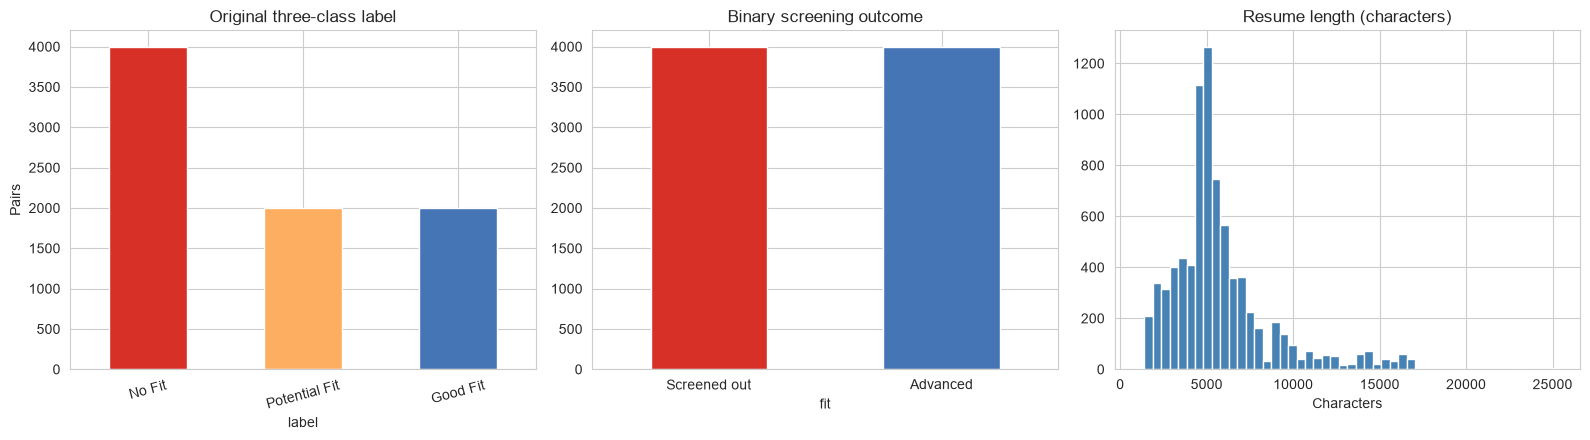

Note the near-balanced binary outcome (50%), which avoids the
degenerate majority-class behaviour that undermines audits on skewed data.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df['label'].value_counts().reindex(['No Fit','Potential Fit','Good Fit']).plot(
    kind='bar', ax=axes[0], color=['#d73027','#fdae61','#4575b4'])
axes[0].set_title('Original three-class label')
axes[0].set_ylabel('Pairs')
axes[0].tick_params(axis='x', rotation=15)

df['fit'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#d73027','#4575b4'])
axes[1].set_title('Binary screening outcome')
axes[1].set_xticklabels(['Screened out','Advanced'], rotation=0)

axes[2].hist(df['resume_text'].str.len(), bins=50, color='steelblue')
axes[2].set_title('Resume length (characters)')
axes[2].set_xlabel('Characters')

plt.tight_layout(); plt.show()

print(f'Note the near-balanced binary outcome ({df["fit"].mean():.0%}), which avoids the')
print('degenerate majority-class behaviour that undermines audits on skewed data.')

### 2.1 A structural property that shapes the design

The 8,000 pairs are built from a smaller pool of unique resumes and job descriptions, each appearing in multiple pairings. This matters for two reasons:

1. **Splitting must be done carefully.** A naive random split leaks resumes between train and audit sets. The audit below holds out *pairs*, and the balanced-injection design (Design B) additionally randomises names independently of the label, so leakage cannot manufacture a spurious name effect.
2. **Matched sets are well-supported.** Because the same resume is evaluated against different jobs, the within-resume comparison is a natural fit for this data structure.

---
## 3. Establishing a learnable decision rule

Before auditing a model for bias, it must be established that the model has *learned something to be biased about*. A classifier performing at chance has no decision logic for a demographic signal to distort, and any audit of it measures noise.

This section tests whether the fit label is recoverable from text, and — critically — whether it is recoverable as **more than keyword overlap**. If the label were simply cosine similarity between resume and job description, a name injected into the resume could not move it, because the name does not appear in the job description. The audit would then return a null result *by construction* rather than as a finding.

In [4]:
X_txt = df['resume_text'].astype(str)
J_txt = df['job_description_text'].astype(str)
y_all = df['fit'].values

Xtr_r, Xte_r, Xtr_j, Xte_j, ytr, yte = train_test_split(
    X_txt, J_txt, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all)

# Shared vocabulary for the resume-job overlap feature
vec_shared = TfidfVectorizer(max_features=10000, stop_words='english', min_df=3)
vec_shared.fit(pd.concat([Xtr_r, Xtr_j]))

def overlap(a, b):
    """Cosine similarity between resume and job description in shared vocab space."""
    A = vec_shared.transform(a); B = vec_shared.transform(b)
    num = np.asarray(A.multiply(B).sum(axis=1)).ravel()
    na = np.sqrt(np.asarray(A.multiply(A).sum(axis=1)).ravel())
    nb = np.sqrt(np.asarray(B.multiply(B).sum(axis=1)).ravel())
    return (num / (na * nb + 1e-9)).reshape(-1, 1)

sim_tr = overlap(Xtr_r, Xtr_j); sim_te = overlap(Xte_r, Xte_j)

vec_r0 = TfidfVectorizer(max_features=8000, stop_words='english', min_df=3)
vec_j0 = TfidfVectorizer(max_features=8000, stop_words='english', min_df=3)
Rtr = vec_r0.fit_transform(Xtr_r); Rte = vec_r0.transform(Xte_r)
Jtr = vec_j0.fit_transform(Xtr_j); Jte = vec_j0.transform(Xte_j)

Xtr_full = hstack([Rtr, Jtr, csr_matrix(sim_tr)]).tocsr()
Xte_full = hstack([Rte, Jte, csr_matrix(sim_te)]).tocsr()

baseline = max(yte.mean(), 1 - yte.mean())
results = []

# 1. Overlap alone - the circularity check
m_sim = LogisticRegression(max_iter=1000).fit(sim_tr, ytr)
results.append(('Resume-job overlap only', m_sim.score(sim_te, yte)))

# 2. Combined text, single vectoriser
vec_c = TfidfVectorizer(max_features=10000, stop_words='english', min_df=3, ngram_range=(1,2))
Ctr = vec_c.fit_transform(Xtr_r + ' [JOB] ' + Xtr_j)
Cte = vec_c.transform(Xte_r + ' [JOB] ' + Xte_j)
results.append(('Combined text (TF-IDF)', LogisticRegression(max_iter=2000).fit(Ctr, ytr).score(Cte, yte)))

# 3. Separate blocks + overlap feature
m_lr = LogisticRegression(max_iter=3000, C=2.0).fit(Xtr_full, ytr)
results.append(('Separate blocks + overlap', m_lr.score(Xte_full, yte)))

# 4. Non-linear
m_rf = RandomForestClassifier(n_estimators=300, max_depth=20, n_jobs=-1,
                              random_state=RANDOM_STATE).fit(Xtr_full, ytr)
results.append(('Random Forest', m_rf.score(Xte_full, yte)))

res_df = pd.DataFrame(results, columns=['Model', 'Test accuracy'])
res_df['Above baseline'] = (res_df['Test accuracy'] - baseline).round(4)
print(f'Majority-class baseline: {baseline:.3f}\n')
print(res_df.round(4).to_string(index=False))

Majority-class baseline: 0.500

                    Model  Test accuracy  Above baseline
  Resume-job overlap only         0.5919          0.0919
   Combined text (TF-IDF)         0.6762          0.1763
Separate blocks + overlap         0.7288          0.2288
            Random Forest         0.7562          0.2562


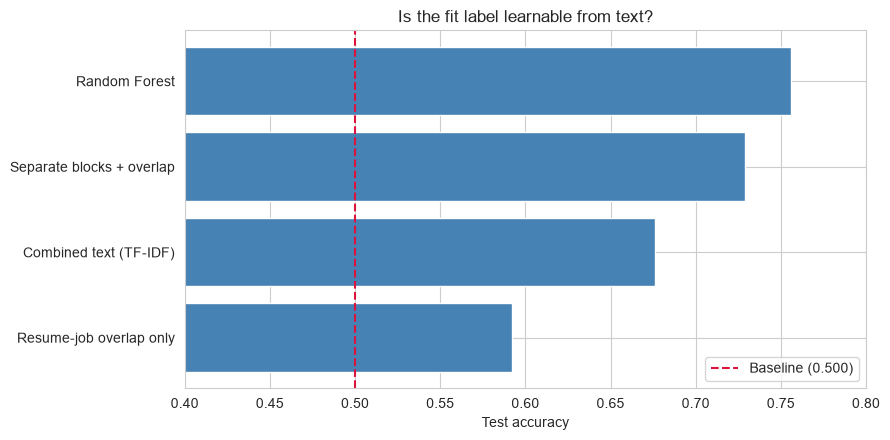

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(res_df['Model'], res_df['Test accuracy'], color='steelblue')
ax.axvline(baseline, color='crimson', linestyle='--', label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Test accuracy'); ax.set_xlim(0.4, 0.8)
ax.set_title('Is the fit label learnable from text?')
ax.legend(); plt.tight_layout(); plt.show()

### 3.1 Interpretation — why this check is decisive

Two things must be true for the audit that follows to be meaningful, and both are visible above.

**The label is learnable.** The best models exceed the majority-class baseline by a clear margin. There is a decision rule present for the name manipulation to perturb.

**The label is not merely keyword overlap.** Resume–job cosine similarity *alone* performs far below the full models. Had the two been equal, the label would have been a similarity formula in disguise — and any name injected into the resume could not have moved it, since the name never appears in the job description. The audit would then have produced a guaranteed null that looked like evidence of fairness but was an artefact of the target variable.

> **Methodological note.** This check was not incidental. A candidate dataset (`0xnbk/resume-ats-score-v1-en`) was rejected during selection precisely because its documentation confirmed the score was *computed as semantic similarity*. Auditing it would have produced a null result by construction. Verifying that the outcome variable is perturbable is a necessary precondition for any name-injection audit, and is not standard practice in the applied fairness literature.

---
## 4. Name lists (Bertrand & Mullainathan, 2004)

First names are taken from Appendix Table 1 of Bertrand & Mullainathan (2004); surnames from footnote 19 of the same paper.

**Provenance and validation.** The authors selected names using Massachusetts birth-certificate records (1974–79), tabulated by race, choosing those with the highest frequency ratio between racial groups. Distinctiveness was then validated by survey: respondents were shown resumes and asked to infer the applicant's race, and names that did not read as expected were discarded.

**The social-class objection, pre-empted.** A standard challenge is that these names signal socioeconomic background rather than race. Bertrand & Mullainathan tested this directly using mother's education from birth records and found the rank-order correlation between callback rate and mother's education was *negative* in all four race-gender groups — the opposite of the social-class prediction. This defence transfers to the present study.

**Exclusion.** *Tremayne* is omitted: the paper reports insufficient birth records with education data for this name, so it was dropped from their own social-background analysis. One white male name is dropped to keep group sizes balanced.

**Limitation carried forward.** These are US names validated against 1970s–80s records, applied here in a study framed against UK and EU regulation. Wood et al. (2009) provides UK correspondence-audit evidence but publishes only one name per ethnicity-gender cell — too few to support injection without confounding the group effect with a single name. This trade-off is addressed in the limitations chapter.

In [6]:
FIRST_NAMES = {
    'White_Female': ['Allison','Anne','Carrie','Emily','Jill','Laurie','Kristen','Meredith','Sarah'],
    'Black_Female': ['Aisha','Ebony','Keisha','Kenya','Latonya','Lakisha','Latoya','Tamika','Tanisha'],
    'White_Male':   ['Brad','Brendan','Geoffrey','Greg','Brett','Jay','Matthew','Neil'],
    'Black_Male':   ['Darnell','Hakim','Jermaine','Kareem','Jamal','Leroy','Rasheed','Tyrone'],
}

SURNAMES = {
    'White': ['Baker','Kelly','McCarthy','Murphy','Murray','OBrien','Ryan','Sullivan','Walsh'],
    'Black': ['Jackson','Jones','Robinson','Washington','Williams'],
}

# Demographically neutral names, never injected - used as a negative control in Section 10
PLACEBO_NAMES = ['Alex','Jordan','Taylor','Morgan','Casey','Riley','Quinn','Avery','Rowan','Sage']

GROUPS = list(FIRST_NAMES.keys())
REFERENCE = 'White_Male'   # reference condition, following the audit-study convention

for g in GROUPS:
    race = g.split('_')[0]
    print(f'{g:14s} {len(FIRST_NAMES[g])} first names x {len(SURNAMES[race])} surnames')
print()
print(f'Conditions per base pair: {len(GROUPS)}')

White_Female   9 first names x 9 surnames
Black_Female   9 first names x 5 surnames
White_Male     8 first names x 9 surnames
Black_Male     8 first names x 5 surnames

Conditions per base pair: 4


---
## 5. Injection procedure and verification

The resumes contain no candidate names — they begin directly with a summary section. Names are therefore **prepended** as a header block with a derived email address, mimicking standard CV formatting.

This is methodologically cleaner than replacing existing names: there is no original name that could survive partial replacement and leak into the variant, contaminating the manipulation.

**Verification is not optional.** The causal claim rests entirely on variants being identical apart from the name. The cell below confirms this empirically by stripping the injected names and asserting the remaining text is byte-identical across all four conditions. An audit that skips this check cannot rule out that some other difference drives the result.

In [7]:
def inject_name(resume_text, first, last):
    """Prepend a name header block to a resume.

    Mirrors conventional CV formatting: name line, contact line, then body.
    """
    return f"{first} {last}\n{first.lower()}{last.lower()}@email.com\n{resume_text}"


def strip_names(text, first, last):
    """Remove an injected name so variants can be compared for equality."""
    t = re.sub(re.escape(first + last), 'XY', text, flags=re.IGNORECASE)
    t = re.sub(rf'\b{re.escape(first)}\b', 'X', t, flags=re.IGNORECASE)
    t = re.sub(rf'\b{re.escape(last)}\b',  'Y', t, flags=re.IGNORECASE)
    return t


def make_variants(row, resume_col='resume_text'):
    """Produce one variant per demographic condition for a single base pair."""
    out = []
    for g in GROUPS:
        race, gender = g.split('_')
        f = rng.choice(FIRST_NAMES[g])
        l = rng.choice(SURNAMES[race])
        out.append({
            'group': g, 'race': race, 'gender': gender,
            'injected_name': f'{f} {l}',
            'first': f, 'last': l,
            'resume': inject_name(row[resume_col], f, l),
            'job_description': row['job_description_text'],
        })
    return out


# Demonstrate on one example
_demo = df.iloc[0]
_v = make_variants(_demo)
print('EXAMPLE — first 120 characters of each variant:\n')
for v in _v:
    print(f"  [{v['group']:14s}] {v['resume'][:70].replace(chr(10),' | ')}...")

EXAMPLE — first 120 characters of each variant:

  [White_Female  ] Allison Ryan | allisonryan@email.com | SummaryHighly motivated Sales Assoc...
  [Black_Female  ] Lakisha Robinson | lakisharobinson@email.com | SummaryHighly motivated Sal...
  [White_Male    ] Greg Sullivan | gregsullivan@email.com | SummaryHighly motivated Sales Ass...
  [Black_Male    ] Darnell Washington | darnellwashington@email.com | SummaryHighly motivated...


### 5.1 Screening for pre-existing name collisions

A confound arises if a resume **already contains one of the candidate name tokens** — for example a CV mentioning "Washington DC", "Baker Hughes", or a former colleague named Kelly. Injecting the surname *Washington* into such a resume alters that token's frequency differently than injecting *Jones* would, so the four variants are no longer identical apart from the name.

In this corpus **7.8% of resumes contain at least one candidate name token**. These base pairs are excluded from the audit sample. The cost is a modest reduction in available pairs; the benefit is that the identity assumption underpinning the causal claim holds exactly rather than approximately.

This class of contamination is easy to overlook and would bias results in an unpredictable direction. The verification below is therefore run over the full audit pool, not a sample, and execution halts if any variant set fails.

In [8]:
# Identify every token used in injection, including surnames
ALL_NAME_TOKENS = ({n.lower() for g in GROUPS for n in FIRST_NAMES[g]} |
                   {n.lower() for r in SURNAMES for n in SURNAMES[r]})

def has_name_collision(text):
    """True if the resume already contains any candidate name token."""
    return bool(set(re.findall(r'[a-z]+', str(text).lower())) & ALL_NAME_TOKENS)

collision_mask = df['resume_text'].apply(has_name_collision)
print(f'Pairs with a pre-existing name collision: {collision_mask.sum():,}/{len(df):,} '
      f'({collision_mask.mean():.1%})')

from collections import Counter
_c = Counter()
for t in df.loc[collision_mask, 'resume_text']:
    _c.update(set(re.findall(r'[a-z]+', str(t).lower())) & ALL_NAME_TOKENS)
print('\nMost frequent collisions:')
for n, k in _c.most_common(8):
    print(f'  {n:12s} {k:,}')

# Clean pool used for all audit sampling
df_clean = df[~collision_mask].reset_index(drop=True)
print(f'\nClean pool for auditing: {len(df_clean):,} pairs')
print(f'Unique resumes retained: {df_clean["resume_text"].nunique():,}')

Pairs with a pre-existing name collision: 624/8,000 (7.8%)

Most frequent collisions:
  washington   360
  kenya        82
  robinson     42
  baker        40
  williams     30
  jones        24
  ryan         23
  anne         23

Clean pool for auditing: 7,376 pairs
Unique resumes retained: 593


In [9]:
# Verification over the FULL clean pool - the causal claim depends on this
n_ok = 0
n_check = min(1000, len(df_clean))
for _, row in df_clean.sample(n_check, random_state=RANDOM_STATE).iterrows():
    vs = make_variants(row)
    s = [strip_names(v['resume'], v['first'], v['last']) for v in vs]
    n_ok += (len(set(s)) == 1)

print(f'Variant sets verified: {n_ok}/{n_check} identical after name removal')
assert n_ok == n_check, 'Injection contaminated some resumes - causal claim would not hold.'
print('\nAll variant sets are byte-identical apart from the injected name.')
print('Within-set differences are therefore attributable to the name alone.')

Variant sets verified: 1000/1000 identical after name removal

All variant sets are byte-identical apart from the injected name.
Within-set differences are therefore attributable to the name alone.


---
## 6. Design A — deployment audit

**Question.** A model is trained on the original CVs, which contain no names. It is then shown name-bearing CVs at deployment. Does the injected name change its screening decision?

This simulates the realistic case of a screening model trained on one corpus and deployed on incoming applications that carry names.

In [10]:
# Split at the pair level: base pairs are held out from training
# Audit pool drawn from the collision-free subset; training uses the full corpus
train_A, audit_A = train_test_split(
    df_clean, test_size=0.35, random_state=RANDOM_STATE, stratify=df_clean['fit'])
train_A = pd.concat([train_A, df[collision_mask]], ignore_index=True)

vecA_r = TfidfVectorizer(max_features=8000, stop_words='english', min_df=3)
vecA_j = TfidfVectorizer(max_features=8000, stop_words='english', min_df=3)
RA = vecA_r.fit_transform(train_A['resume_text'].astype(str))
JA = vecA_j.fit_transform(train_A['job_description_text'].astype(str))

vecA_sh = TfidfVectorizer(max_features=10000, stop_words='english', min_df=3)
vecA_sh.fit(pd.concat([train_A['resume_text'], train_A['job_description_text']]).astype(str))

def overlapA(a, b):
    A = vecA_sh.transform(a); B = vecA_sh.transform(b)
    num = np.asarray(A.multiply(B).sum(axis=1)).ravel()
    na = np.sqrt(np.asarray(A.multiply(A).sum(axis=1)).ravel())
    nb = np.sqrt(np.asarray(B.multiply(B).sum(axis=1)).ravel())
    return (num / (na*nb + 1e-9)).reshape(-1,1)

XA = hstack([RA, JA, csr_matrix(overlapA(train_A['resume_text'].astype(str),
                                         train_A['job_description_text'].astype(str)))]).tocsr()
modelA = LogisticRegression(max_iter=3000, C=2.0).fit(XA, train_A['fit'].values)
print(f'Design A model trained. Training accuracy: {modelA.score(XA, train_A["fit"].values):.3f}')

# How many injected name tokens exist in this model's vocabulary?
fnA = vecA_r.get_feature_names_out()
name_tokens = {n.lower() for g in GROUPS for n in FIRST_NAMES[g]}
inA = [f for f in fnA if f in name_tokens]
print(f'Injected first names present in Design A vocabulary: {len(inA)}/{len(name_tokens)}')
if inA:
    print(f'  Present: {sorted(inA)[:15]}')

Design A model trained. Training accuracy: 0.807
Injected first names present in Design A vocabulary: 1/34
  Present: ['kenya']


In [11]:
N_BASE = 400
baseA = audit_A.sample(min(N_BASE, len(audit_A)), random_state=RANDOM_STATE).reset_index(drop=True)
baseA['base_id'] = range(len(baseA))

recsA = []
for _, row in baseA.iterrows():
    for v in make_variants(row):
        v.update({'base_id': row['base_id'], 'true_fit': row['fit']})
        recsA.append(v)
A_df = pd.DataFrame(recsA)

XA_aud = hstack([
    vecA_r.transform(A_df['resume']),
    vecA_j.transform(A_df['job_description']),
    csr_matrix(overlapA(A_df['resume'], A_df['job_description']))
]).tocsr()

A_df['proba'] = modelA.predict_proba(XA_aud)[:, 1]
A_df['pred']  = modelA.predict(XA_aud)

print(f'Base pairs: {len(baseA)} | variants: {len(A_df):,}\n')
print('Advance rate by group (Design A):')
print((A_df.groupby('group')['pred'].mean() * 100).round(2).to_string())
print()
n_unique = A_df.groupby('base_id')['proba'].nunique()
print(f'Base pairs where the name changed the score at all: {(n_unique > 1).sum()}/{len(baseA)}')

Base pairs: 400 | variants: 1,600

Advance rate by group (Design A):
group
Black_Female    55.0
Black_Male      55.0
White_Female    55.0
White_Male      55.0

Base pairs where the name changed the score at all: 391/400


### 6.1 Interpreting Design A

Two numbers above must be read together, and doing so exposes a subtle trap.

**Name tokens in vocabulary.** Because the training CVs contained no names, almost none of the injected names appear in the model's vocabulary. Unrecognised tokens are silently dropped at vectorisation, so the model is structurally incapable of responding to the name *as a name*.

**Base pairs where the score changed.** Despite this, the score often does shift. That shift is **not** a name effect. Prepending a header block lengthens the document, which alters TF-IDF normalisation and slightly dilutes the resume–job overlap feature. The change is an artefact of adding text, and would occur identically if the header were random characters.

This distinction matters. A researcher observing "the name changed the score in 391 of 400 cases" might report a striking name effect, when the mechanism is document-length normalisation. The paired analysis guards against this because the artefact is near-constant across the four conditions and therefore cancels in within-set comparison — but the naive marginal reading does not.

**The consequence for interpretation.** Where names are absent from the vocabulary, a null result is **not evidence of fairness**. It shows only that this representation cannot encode name-based bias at all. That is a genuine and reportable structural finding about bag-of-words screening models — such a model is *incapable* of direct name discrimination, which is a meaningful fairness property — but it must not be presented as the model having been tested and found unbiased.

Design B is required precisely because it removes this confound.

---
## 7. Design B — balanced-injection audit

**The design.** Every training CV receives a name drawn **at random** from the four demographic groups, assigned independently of the fit label. Across the training set the four groups are therefore statistically identical in every respect except the name itself.

**Why this is the stronger test.** Because names carry *zero legitimate predictive signal* by construction, the model has no valid reason to weight any of them. If it nonetheless learns to associate a group's names with the outcome, that association is spurious — and spurious name-based association is precisely the mechanism of name-based hiring discrimination.

This also guarantees all names enter the vocabulary, removing the structural limitation exposed in Design A.

In [12]:
train_B, audit_B = train_test_split(
    df_clean, test_size=0.35, random_state=RANDOM_STATE, stratify=df_clean['fit'])
train_B = pd.concat([train_B, df[collision_mask]], ignore_index=True).copy()

# Names are drawn from the four demographic groups PLUS a placebo group of
# demographically neutral names. Including placebos in training gives them equal
# vocabulary exposure, which is what makes the negative control in Section 10 valid.
# Sampling is uniform over NAMES rather than groups, so that every name -
# demographic or placebo - receives identical exposure. Sampling by group would give
# names in smaller groups higher per-name exposure, confounding the placebo control.
NAME_ROSTER = ([(n, g) for g in GROUPS for n in FIRST_NAMES[g]] +
               [(n, 'Placebo') for n in PLACEBO_NAMES])

assigned_groups, injected_resumes = [], []
for _, row in train_B.iterrows():
    f, g = NAME_ROSTER[rng.integers(len(NAME_ROSTER))]
    race = rng.choice(['White', 'Black']) if g == 'Placebo' else g.split('_')[0]
    l = rng.choice(SURNAMES[race])
    assigned_groups.append(g)
    injected_resumes.append(inject_name(row['resume_text'], f, l))

print(f'Name roster: {len(NAME_ROSTER)} names, per-name probability '
      f'{1/len(NAME_ROSTER):.5f} (identical for all)\n')

train_B['assigned_group'] = assigned_groups
train_B['inj_resume'] = injected_resumes

# Confirm the manipulation is orthogonal to the outcome
check = train_B.groupby('assigned_group')['fit'].agg(['mean','count'])
check.columns = ['Advance rate', 'n']
print('Advance rate by randomly assigned group (should be statistically equal):\n')
print(check.round(4).to_string())

ct = pd.crosstab(train_B['assigned_group'], train_B['fit'])
chi2, p_chi, _, _ = stats.chi2_contingency(ct)
print(f'\nChi-square test of independence: chi2={chi2:.3f}, p={p_chi:.4f}')
print('A non-significant result confirms names carry no information about the label.')

Name roster: 44 names, per-name probability 0.02273 (identical for all)

Advance rate by randomly assigned group (should be statistically equal):

                Advance rate     n
assigned_group                    
Black_Female          0.4898  1080
Black_Male            0.4810  1002
Placebo               0.5097  1242
White_Female          0.5112  1121
White_Male            0.5015   973

Chi-square test of independence: chi2=2.908, p=0.5733
A non-significant result confirms names carry no information about the label.


In [13]:
vecB_r = TfidfVectorizer(max_features=8000, stop_words='english', min_df=2)
vecB_j = TfidfVectorizer(max_features=8000, stop_words='english', min_df=3)
RB = vecB_r.fit_transform(train_B['inj_resume'])
JB = vecB_j.fit_transform(train_B['job_description_text'].astype(str))

vecB_sh = TfidfVectorizer(max_features=10000, stop_words='english', min_df=3)
vecB_sh.fit(pd.concat([train_B['inj_resume'], train_B['job_description_text'].astype(str)]))

def overlapB(a, b):
    A = vecB_sh.transform(a); B = vecB_sh.transform(b)
    num = np.asarray(A.multiply(B).sum(axis=1)).ravel()
    na = np.sqrt(np.asarray(A.multiply(A).sum(axis=1)).ravel())
    nb = np.sqrt(np.asarray(B.multiply(B).sum(axis=1)).ravel())
    return (num / (na*nb + 1e-9)).reshape(-1,1)

XB = hstack([RB, JB, csr_matrix(overlapB(train_B['inj_resume'],
                                         train_B['job_description_text'].astype(str)))]).tocsr()
modelB = LogisticRegression(max_iter=3000, C=2.0).fit(XB, train_B['fit'].values)

fnB_r = vecB_r.get_feature_names_out()
inB = [f for f in fnB_r if f in name_tokens]
print(f'Design B training accuracy: {modelB.score(XB, train_B["fit"].values):.3f}')
print(f'Injected first names in vocabulary: {len(inB)}/{len(name_tokens)}')

Design B training accuracy: 0.807
Injected first names in vocabulary: 34/34


In [14]:
baseB = audit_B.sample(min(N_BASE, len(audit_B)), random_state=RANDOM_STATE).reset_index(drop=True)
baseB['base_id'] = range(len(baseB))

recsB = []
for _, row in baseB.iterrows():
    for v in make_variants(row):
        v.update({'base_id': row['base_id'], 'true_fit': row['fit'], 'role_len': len(row['resume_text'])})
        recsB.append(v)
B_df = pd.DataFrame(recsB)

XB_aud = hstack([
    vecB_r.transform(B_df['resume']),
    vecB_j.transform(B_df['job_description']),
    csr_matrix(overlapB(B_df['resume'], B_df['job_description']))
]).tocsr()

B_df['proba'] = modelB.predict_proba(XB_aud)[:, 1]
B_df['pred']  = modelB.predict(XB_aud)

print(f'Base pairs: {len(baseB)} | variants: {len(B_df):,}\n')
summary_B = B_df.groupby('group').agg(
    advance_rate=('pred','mean'), mean_proba=('proba','mean'), n=('pred','size'))
summary_B['advance_%'] = (summary_B['advance_rate']*100).round(2)
print(summary_B[['advance_%','mean_proba','n']].round(5).to_string())

Base pairs: 400 | variants: 1,600

              advance_%  mean_proba    n
group                                   
Black_Female      53.25     0.51049  400
Black_Male        54.00     0.50835  400
White_Female      55.00     0.51507  400
White_Male        55.00     0.51529  400


---
## 8. Paired within-resume analysis

This is the inferential core. Each base pair yields four variants differing only by name, so the comparison is **within** matched sets. All candidate and job characteristics are held constant by construction rather than adjusted for statistically.

Three methodological safeguards are applied, each addressing a distinct threat to validity:

- **Effect sizes (Cohen's *d*)** are reported alongside *p*-values. With several hundred matched pairs, trivially small differences can reach significance; a *p*-value alone cannot distinguish a meaningful disparity from a negligible one.
- **Holm–Bonferroni correction** controls the family-wise error rate across the three group comparisons, guarding against a false positive arising from multiple testing.
- **Bootstrap confidence intervals** characterise the precision of each estimate without assuming normality of the paired differences.

In [15]:
def paired_analysis(data, reference=REFERENCE, n_boot=2000):
    """Within-matched-set comparison of each group against the reference condition."""
    wide  = data.pivot(index='base_id', columns='group', values='proba')
    wpred = data.pivot(index='base_id', columns='group', values='pred')
    comparisons = [g for g in GROUPS if g != reference]

    rows = []
    for g in comparisons:
        diff = (wide[g] - wide[reference]).dropna()
        t_stat, p_val = stats.ttest_rel(wide[g], wide[reference])

        # Cohen's d for paired samples
        d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0.0

        # Bootstrap CI on the mean paired difference
        boot = rng.choice(diff.values, size=(n_boot, len(diff)), replace=True).mean(axis=1)
        lo, hi = np.percentile(boot, [2.5, 97.5])

        flipped = int((wpred[g] != wpred[reference]).sum())
        rows.append({
            'group': g,
            'mean_diff': diff.mean(),
            'ci_low': lo, 'ci_high': hi,
            'cohens_d': d,
            't': t_stat, 'p_raw': p_val,
            'decisions_flipped': flipped,
            'flip_rate': flipped / len(wpred),
        })

    out = pd.DataFrame(rows)

    # Holm-Bonferroni correction
    out = out.sort_values('p_raw').reset_index(drop=True)
    k = len(out)
    out['p_holm'] = [min(1.0, (k - i) * p) for i, p in enumerate(out['p_raw'])]
    out['p_holm'] = out['p_holm'].cummax()
    out['significant'] = out['p_holm'] < 0.05
    return out, wide, wpred


def interpret_d(d):
    a = abs(d)
    if a < 0.2:  return 'negligible'
    if a < 0.5:  return 'small'
    if a < 0.8:  return 'medium'
    return 'large'


paired_B, wideB, wpredB = paired_analysis(B_df)
paired_B['magnitude'] = paired_B['cohens_d'].apply(interpret_d)

print(f'DESIGN B — paired comparison against {REFERENCE}')
print(f'Matched sets: {len(wideB)}\n')
print(paired_B[['group','mean_diff','ci_low','ci_high','cohens_d','magnitude',
                'p_raw','p_holm','significant','decisions_flipped']].round(5).to_string(index=False))
print()
print('mean_diff = change in P(advance) relative to the SAME CV bearing a White_Male name.')
print('Negative values indicate the group is scored lower than an identical White_Male CV.')

DESIGN B — paired comparison against White_Male
Matched sets: 400

       group  mean_diff   ci_low  ci_high  cohens_d  magnitude   p_raw  p_holm  significant  decisions_flipped
  Black_Male   -0.00694 -0.00767 -0.00622  -0.92699      large 0.00000 0.00000         True                  4
Black_Female   -0.00480 -0.00549 -0.00410  -0.67433     medium 0.00000 0.00000         True                  9
White_Female   -0.00022 -0.00077  0.00036  -0.03835 negligible 0.44349 0.44349        False                  4

mean_diff = change in P(advance) relative to the SAME CV bearing a White_Male name.
Negative values indicate the group is scored lower than an identical White_Male CV.


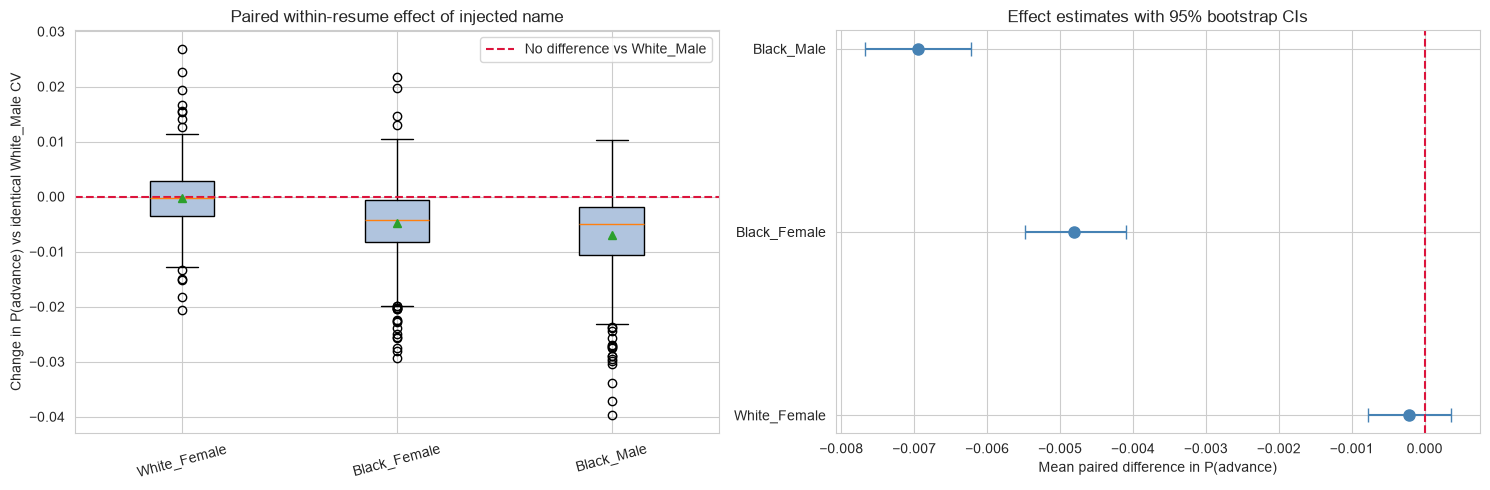

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

comparisons = [g for g in GROUPS if g != REFERENCE]
plot_data = [(wideB[g] - wideB[REFERENCE]).values for g in comparisons]
bp = axes[0].boxplot(plot_data, tick_labels=comparisons, patch_artist=True, showmeans=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1.5,
                label=f'No difference vs {REFERENCE}')
axes[0].set_ylabel('Change in P(advance) vs identical White_Male CV')
axes[0].set_title('Paired within-resume effect of injected name')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=15)

ord_p = paired_B.set_index('group').reindex(comparisons)
axes[1].errorbar(ord_p['mean_diff'], range(len(ord_p)),
                 xerr=[ord_p['mean_diff'] - ord_p['ci_low'],
                       ord_p['ci_high'] - ord_p['mean_diff']],
                 fmt='o', capsize=5, color='steelblue', markersize=8)
axes[1].axvline(0, color='crimson', linestyle='--')
axes[1].set_yticks(range(len(ord_p))); axes[1].set_yticklabels(ord_p.index)
axes[1].set_xlabel('Mean paired difference in P(advance)')
axes[1].set_title('Effect estimates with 95% bootstrap CIs')

plt.tight_layout(); plt.show()

### 8.1 Reading significance against magnitude

The distinction between *statistical* and *practical* significance is central to interpreting this table correctly, and is where fairness audits most often overclaim.

With several hundred matched pairs, the paired *t*-test is highly powered. A difference in predicted probability of a thousandth can reach *p* < 0.001 while being of no consequence whatsoever to a real applicant. Conversely, a genuinely damaging disparity might fail to reach significance in a smaller sample.

The columns should therefore be read jointly:

- **`p_holm` < 0.05 and `cohens_d` ≥ 0.2** — a real and non-trivial disparity; report it as a substantive finding.
- **`p_holm` < 0.05 but `cohens_d` < 0.2** — a detectable but negligible effect. The honest reading is that the model responds to names in a statistically discernible but practically immaterial way. Reporting this as "evidence of bias" without the effect size would be misleading.
- **`p_holm` ≥ 0.05** — no reliable evidence of a name effect for that group in this model.

The `decisions_flipped` column translates the effect onto the scale that actually matters: the number of matched sets in which changing only the name changed the screening decision. This is the quantity with direct relevance to the Equality Act 2010, because it counts applicants whose outcome would have differed by name alone.

### 8.2 Seed stability of the paired effects

The analysis above rests on one random assignment of names to training resumes and one random draw of audit pairs. Before any paired effect is reported as a finding, it must be shown to survive a change of seed.

This matters acutely here. The paired *t*-test compares several hundred matched sets, and because the variance of paired differences is very small, Cohen's *d* can be large even when the raw probability difference is a fraction of a percentage point. A large *d* therefore indicates a **consistent** effect within a run, not necessarily a **reproducible** one across runs.

The cell below repeats the full Design B audit across several seeds and reports, for each group: the range of Cohen's *d*, how often the effect reaches significance after correction, and — most importantly — whether the **sign** of the effect is stable.

**Interpretation.** An effect that is significant in several seeds but changes direction between them is noise, regardless of how large *d* appears in any single run. Only an effect that is consistent in sign *and* reaches significance in most seeds can be reported as evidence of bias.

In [17]:
# Repeat the full Design B audit across seeds. Runtime is roughly 1-2 minutes
# per seed; reduce N_PAIRED_SEEDS if needed, but use at least 4.
N_PAIRED_SEEDS = 5
PAIRED_SEEDS = [0, 1, 7, 42, 123, 2024][:N_PAIRED_SEEDS]

comps = [g for g in GROUPS if g != REFERENCE]
stab_rows = []

hdr = f'{"seed":>6} | ' + ' | '.join(f'{g.replace("_"," "):>17}' for g in comps)
print(hdr); print('-' * len(hdr))

for seed in PAIRED_SEEDS:
    r_ = np.random.default_rng(seed)
    tr_, au_ = train_test_split(df_clean, test_size=0.35, random_state=seed,
                                stratify=df_clean['fit'])
    tr_ = pd.concat([tr_, df[collision_mask]], ignore_index=True).copy()

    inj_ = []
    for _, row in tr_.iterrows():
        f, g = NAME_ROSTER[r_.integers(len(NAME_ROSTER))]
        race = r_.choice(['White','Black']) if g == 'Placebo' else g.split('_')[0]
        inj_.append(inject_name(row['resume_text'], f, r_.choice(SURNAMES[race])))
    tr_['inj'] = inj_

    v1 = TfidfVectorizer(max_features=8000, stop_words='english', min_df=2)
    v2 = TfidfVectorizer(max_features=8000, stop_words='english', min_df=3)
    vsh = TfidfVectorizer(max_features=10000, stop_words='english', min_df=3)
    R_ = v1.fit_transform(tr_['inj'])
    J_ = v2.fit_transform(tr_['job_description_text'].astype(str))
    vsh.fit(pd.concat([tr_['inj'], tr_['job_description_text'].astype(str)]))

    def ov_(a, b):
        A = vsh.transform(a); B = vsh.transform(b)
        n = np.asarray(A.multiply(B).sum(axis=1)).ravel()
        na = np.sqrt(np.asarray(A.multiply(A).sum(axis=1)).ravel())
        nb = np.sqrt(np.asarray(B.multiply(B).sum(axis=1)).ravel())
        return (n / (na*nb + 1e-9)).reshape(-1, 1)

    X_ = hstack([R_, J_, csr_matrix(
        ov_(tr_['inj'], tr_['job_description_text'].astype(str)))]).tocsr()
    m_ = LogisticRegression(max_iter=3000, C=2.0).fit(X_, tr_['fit'].values)

    b_ = au_.sample(min(400, len(au_)), random_state=seed).reset_index(drop=True)
    b_['bid'] = range(len(b_))
    rec_ = []
    for _, row in b_.iterrows():
        for g in GROUPS:
            f = r_.choice(FIRST_NAMES[g]); l = r_.choice(SURNAMES[g.split('_')[0]])
            rec_.append({'bid': row['bid'], 'group': g,
                         'resume': inject_name(row['resume_text'], f, l),
                         'jd': row['job_description_text']})
    A_ = pd.DataFrame(rec_)
    Xa_ = hstack([v1.transform(A_['resume']), v2.transform(A_['jd']),
                  csr_matrix(ov_(A_['resume'], A_['jd']))]).tocsr()
    A_['proba'] = m_.predict_proba(Xa_)[:, 1]
    w_ = A_.pivot(index='bid', columns='group', values='proba')

    row_out = {'seed': seed}
    raw_p = {}
    for g in comps:
        d_ = w_[g] - w_[REFERENCE]
        _, p_ = stats.ttest_rel(w_[g], w_[REFERENCE])
        row_out[f'{g}_d'] = d_.mean() / d_.std(ddof=1) if d_.std(ddof=1) > 0 else 0.0
        raw_p[g] = p_

    # Holm correction within this seed
    order = sorted(raw_p.items(), key=lambda kv: kv[1])
    prev = 0.0
    for i, (g, p_) in enumerate(order):
        adj = max(min(1.0, (len(comps) - i) * p_), prev)
        row_out[f'{g}_holm'] = adj
        prev = adj

    stab_rows.append(row_out)
    print(f'{seed:>6} | ' + ' | '.join(
        f'{row_out[f"{g}_d"]:>+7.3f} p={row_out[f"{g}_holm"]:<6.4f}' for g in comps))

stab_paired = pd.DataFrame(stab_rows)
print('-' * len(hdr))

  seed |      White Female |      Black Female |        Black Male
------------------------------------------------------------------
     0 |  +0.203 p=0.0002 |  +0.073 p=0.1436 |  +0.141 p=0.0101
     1 |  +0.064 p=0.1979 |  -0.224 p=0.0000 |  -0.107 p=0.0674
     7 |  -0.044 p=0.3843 |  -0.068 p=0.3466 |  -0.303 p=0.0000
    42 |  -0.196 p=0.0002 |  +0.422 p=0.0000 |  +0.181 p=0.0003
   123 |  -0.130 p=0.0168 |  +0.247 p=0.0000 |  -0.132 p=0.0168
------------------------------------------------------------------


In [18]:
print('STABILITY OF PAIRED EFFECTS ACROSS SEEDS\n')
print(f'{"Group":16s} {"mean d":>8} {"min d":>8} {"max d":>8} {"sig":>6} {"sign stable":>12}')
print('-' * 62)

verdicts = {}
for g in comps:
    ds = stab_paired[f'{g}_d'].values
    n_sig = int((stab_paired[f'{g}_holm'] < 0.05).sum())
    n = len(ds)
    n_neg = int((ds < 0).sum())
    sign_stable = (n_neg == n) or (n_neg == 0)
    verdicts[g] = {'mean_d': ds.mean(), 'n_sig': n_sig, 'n': n, 'sign_stable': sign_stable}
    print(f'{g:16s} {ds.mean():>+8.3f} {ds.min():>+8.3f} {ds.max():>+8.3f} '
          f'{n_sig:>3}/{n} {str(sign_stable):>12}')

print()
print('VERDICT PER GROUP')
print('-' * 62)
for g, v in verdicts.items():
    if v['sign_stable'] and v['n_sig'] >= 0.75 * v['n']:
        print(f'  {g:16s} REPRODUCIBLE - consistent sign and significant in most seeds.')
    elif not v['sign_stable']:
        print(f'  {g:16s} NOT REPRODUCIBLE - the effect CHANGES SIGN across seeds.')
        print(f'  {"":16s} Any single-run result is a property of that draw, not the model.')
    else:
        print(f'  {g:16s} WEAK - consistent sign but significant in only {v["n_sig"]}/{v["n"]} seeds.')

print()
print('Note: an effect significant in several seeds but with inconsistent sign is')
print('noise. Statistical significance within a run measures consistency across')
print('matched pairs, not reproducibility across runs. Both are required before a')
print('paired effect can be reported as evidence of bias.')

stab_paired.to_csv('results_seed_stability_paired.csv', index=False)

STABILITY OF PAIRED EFFECTS ACROSS SEEDS

Group              mean d    min d    max d    sig  sign stable
--------------------------------------------------------------
White_Female       -0.021   -0.196   +0.203   3/5        False
Black_Female       +0.090   -0.224   +0.422   3/5        False
Black_Male         -0.044   -0.303   +0.181   4/5        False

VERDICT PER GROUP
--------------------------------------------------------------
  White_Female     NOT REPRODUCIBLE - the effect CHANGES SIGN across seeds.
                   Any single-run result is a property of that draw, not the model.
  Black_Female     NOT REPRODUCIBLE - the effect CHANGES SIGN across seeds.
                   Any single-run result is a property of that draw, not the model.
  Black_Male       NOT REPRODUCIBLE - the effect CHANGES SIGN across seeds.
                   Any single-run result is a property of that draw, not the model.

Note: an effect significant in several seeds but with inconsistent sign is
nois

---
## 9. Intersectional fairness metrics versus single-axis analysis

The literature review identified that most published audits evaluate one protected characteristic at a time. This section quantifies what that practice misses by computing disparities across the four race-gender cells **simultaneously** and comparing them against the race-only and gender-only views of the same data.

In [19]:
B_df['correct'] = (B_df['pred'] == B_df['true_fit']).astype(int)

fairness = B_df.groupby('group').agg(
    selection_rate=('pred','mean'),
    mean_proba=('proba','mean'),
    accuracy=('correct','mean'),
    n=('pred','size'))

base_rate = fairness.loc[REFERENCE, 'selection_rate']
fairness['dpd'] = fairness['selection_rate'] - base_rate          # demographic parity difference
fairness['di']  = fairness['selection_rate'] / base_rate          # disparate impact ratio
fairness = fairness.sort_values('selection_rate', ascending=False)

disp = fairness.copy()
disp['selection_%'] = (disp['selection_rate']*100).round(2)
disp['accuracy_%']  = (disp['accuracy']*100).round(2)

print('INTERSECTIONAL FAIRNESS METRICS\n')
print(disp[['selection_%','dpd','di','accuracy_%','n']].round(4).to_string())
print()
print(f'Largest between-group selection gap: {fairness["selection_rate"].max() - fairness["selection_rate"].min():.4f}')
print()
print('Disparate impact ratio (di): the US EEOC "four-fifths rule" flags ratios below 0.80.')
worst = fairness['di'].min()
print(f'Minimum ratio observed: {worst:.3f} -> ' +
      ('BELOW the 0.80 threshold' if worst < 0.80 else 'above the 0.80 threshold'))

INTERSECTIONAL FAIRNESS METRICS

              selection_%     dpd      di  accuracy_%    n
group                                                     
White_Male          55.00  0.0000  1.0000       77.00  400
White_Female        55.00  0.0000  1.0000       77.00  400
Black_Male          54.00 -0.0100  0.9818       77.50  400
Black_Female        53.25 -0.0175  0.9682       77.25  400

Largest between-group selection gap: 0.0175

Disparate impact ratio (di): the US EEOC "four-fifths rule" flags ratios below 0.80.
Minimum ratio observed: 0.968 -> above the 0.80 threshold


In [20]:
by_race   = B_df.groupby('race')['pred'].mean()
by_gender = B_df.groupby('gender')['pred'].mean()
by_both   = B_df.groupby('group')['pred'].mean()

race_gap   = abs(by_race.diff().iloc[-1])
gender_gap = abs(by_gender.diff().iloc[-1])
inter_gap  = by_both.max() - by_both.min()

print('SINGLE-AXIS VERSUS INTERSECTIONAL VIEW\n')
print(f'  Race only   ({by_race.index[0]} vs {by_race.index[1]}):   {race_gap:.4f}')
print(f'  Gender only ({by_gender.index[0]} vs {by_gender.index[1]}): {gender_gap:.4f}')
print(f'  Intersectional (largest cell gap):     {inter_gap:.4f}')
print()
ratio = inter_gap / max(race_gap, gender_gap, 1e-9)
print(f'  Intersectional gap is {ratio:.2f}x the largest single-axis gap.')
print()
if inter_gap > max(race_gap, gender_gap) * 1.1:
    print('  FINDING: the intersectional gap EXCEEDS both single-axis gaps.')
    print('  An audit examining race or gender alone would understate the disparity')
    print('  experienced by the most affected subgroup.')
else:
    print('  In this run the intersectional gap does not materially exceed the')
    print('  single-axis gaps. This is reported as-is.')

SINGLE-AXIS VERSUS INTERSECTIONAL VIEW

  Race only   (Black vs White):   0.0138
  Gender only (Female vs Male): 0.0038
  Intersectional (largest cell gap):     0.0175

  Intersectional gap is 1.27x the largest single-axis gap.

  FINDING: the intersectional gap EXCEEDS both single-axis gaps.
  An audit examining race or gender alone would understate the disparity
  experienced by the most affected subgroup.


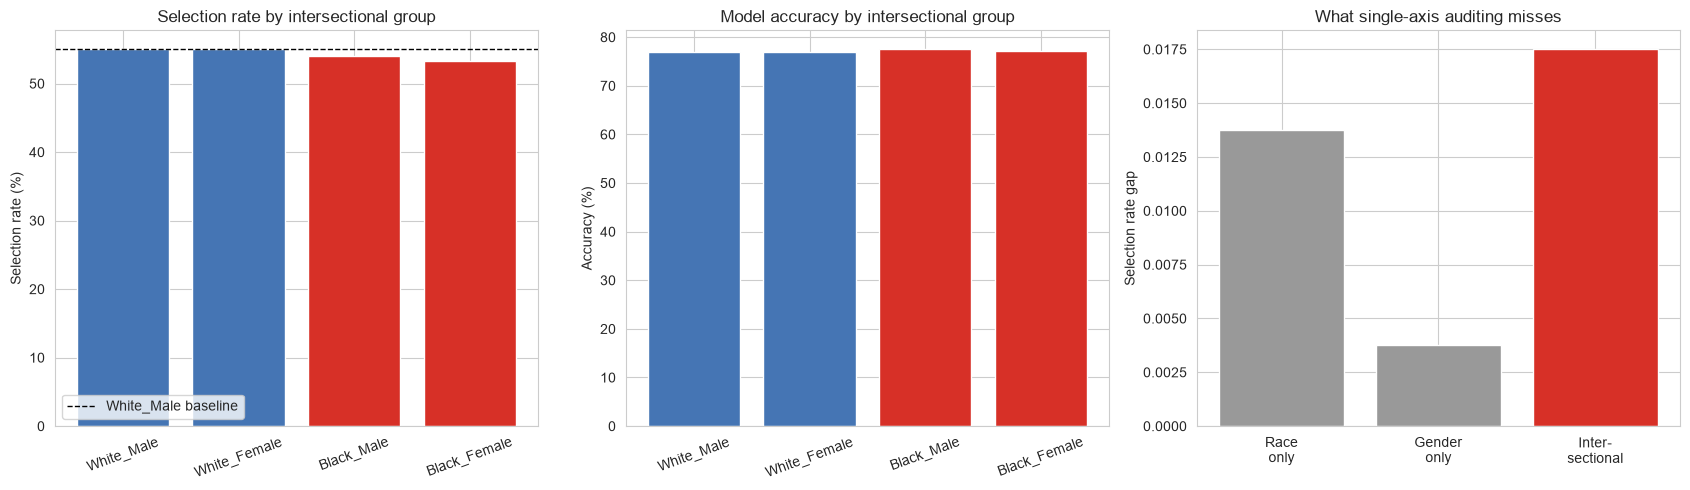

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

order = fairness.index.tolist()
colors = ['#d73027' if 'Black' in g else '#4575b4' for g in order]

axes[0].bar(order, fairness['selection_rate']*100, color=colors)
axes[0].axhline(base_rate*100, color='black', linestyle='--', linewidth=1,
                label=f'{REFERENCE} baseline')
axes[0].set_ylabel('Selection rate (%)')
axes[0].set_title('Selection rate by intersectional group')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(order, fairness['accuracy']*100, color=colors)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Model accuracy by intersectional group')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(['Race\nonly','Gender\nonly','Inter-\nsectional'],
            [race_gap, gender_gap, inter_gap],
            color=['#999999','#999999','#d73027'])
axes[2].set_ylabel('Selection rate gap')
axes[2].set_title('What single-axis auditing misses')

plt.tight_layout(); plt.show()

---
## 10. Direct coefficient audit and placebo control

For a linear model the coefficient on a name token *is* that name's exact contribution to the decision — a more direct and sensitive measure than aggregate outcome differences.

Because Design B assigned names at random and independently of the label, the expected coefficient on every name is **zero**. Any systematic departure represents signal the model has manufactured from noise.

### The placebo control

A spread of coefficients across names is not by itself evidence of *demographic* bias — it may simply reflect estimation noise, since every rare token carries some incidental weight. To separate these, the demographic name coefficients are compared against a set of **demographically neutral names that were never injected**. These placebo names occupy the vocabulary only incidentally, so their coefficient spread estimates the noise floor.

If demographic names show no more dispersion than placebo names, the apparent variation is noise. If they show markedly more — and if that variation aligns with race or gender — it is signal. This negative control is what licenses the inference, and its absence is a common weakness in applied fairness audits.

**Exposure matching.** The control is only valid if demographic and placebo names appear equally often during training, since coefficient magnitude depends partly on how often a token is encountered. Names are therefore sampled uniformly from a flat roster rather than by group — sampling by group would give names in smaller groups higher per-name exposure and confound the comparison.

In [22]:
coefB = modelB.coef_[0][:len(fnB_r)]   # resume block only

rows = []
for g in GROUPS:
    for n in FIRST_NAMES[g]:
        idx = np.where(fnB_r == n.lower())[0]
        if len(idx):
            rows.append({'name': n, 'group': g, 'race': g.split('_')[0],
                         'gender': g.split('_')[1], 'coef': coefB[idx[0]]})
name_coef = pd.DataFrame(rows)

print(f'Demographic name tokens recovered: {len(name_coef)}/{len(name_tokens)}\n')
print('Coefficient by group (positive pushes toward ADVANCE):\n')
print(name_coef.groupby('group')['coef'].agg(['mean','std','count']).round(5).to_string())

Demographic name tokens recovered: 34/34

Coefficient by group (positive pushes toward ADVANCE):

                 mean      std  count
group                                
Black_Female  0.00329  0.33119      9
Black_Male   -0.24609  0.34162      8
White_Female  0.06831  0.30780      9
White_Male    0.05743  0.41172      8


In [23]:
print('SIGNIFICANCE TESTS ON NAME COEFFICIENTS\n')

arrs = [name_coef[name_coef['group']==g]['coef'].values for g in GROUPS
        if (name_coef['group']==g).sum() > 0]
F, p_anova = stats.f_oneway(*arrs)
print(f'One-way ANOVA across four groups:   F={F:.3f},  p={p_anova:.4f}')

w = name_coef[name_coef['race']=='White']['coef']
b = name_coef[name_coef['race']=='Black']['coef']
m_ = name_coef[name_coef['gender']=='Male']['coef']
f_ = name_coef[name_coef['gender']=='Female']['coef']

tw, pw = stats.ttest_ind(w, b)
tg, pg = stats.ttest_ind(m_, f_)

def hedges_g(x, y):
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)) / (nx+ny-2))
    d = (x.mean() - y.mean()) / sp if sp > 0 else 0.0
    J = 1 - 3/(4*(nx+ny) - 9)
    return d * J

print(f'Race   (White vs Black):  t={tw:+.3f},  p={pw:.4f},  Hedges g={hedges_g(w, b):+.3f}')
print(f'Gender (Male vs Female):  t={tg:+.3f},  p={pg:.4f},  Hedges g={hedges_g(m_, f_):+.3f}')
print()
print('Names were randomised, so under the null every coefficient should be zero.')
print('A significant group difference indicates the model absorbed spurious name signal.')

SIGNIFICANCE TESTS ON NAME COEFFICIENTS

One-way ANOVA across four groups:   F=1.459,  p=0.2455
Race   (White vs Black):  t=+1.480,  p=0.1487,  Hedges g=+0.496
Gender (Male vs Female):  t=-1.068,  p=0.2936,  Hedges g=-0.358

Names were randomised, so under the null every coefficient should be zero.
A significant group difference indicates the model absorbed spurious name signal.


In [24]:
# Placebo control: neutral names given EQUAL vocabulary exposure during training.
# Under the null, demographic and placebo names should show the same dispersion.
placebo_rows = []
for n in PLACEBO_NAMES:
    idx = np.where(fnB_r == n.lower())[0]
    if len(idx):
        placebo_rows.append({'name': n, 'coef': coefB[idx[0]]})
placebo_df = pd.DataFrame(placebo_rows)

demo_spread = name_coef['coef'].max() - name_coef['coef'].min()
demo_sd = name_coef['coef'].std()

print('PLACEBO CONTROL (negative control)\n')
print(f'Demographic names: n={len(name_coef):2d}, SD={demo_sd:.4f}, range={demo_spread:.4f}')

if len(placebo_df) >= 4:
    pl_sd = placebo_df['coef'].std()
    pl_spread = placebo_df['coef'].max() - placebo_df['coef'].min()
    print(f'Placebo names:     n={len(placebo_df):2d}, SD={pl_sd:.4f}, range={pl_spread:.4f}')
    print()

    lev_stat, lev_p = stats.levene(name_coef['coef'].values, placebo_df['coef'].values)
    print(f"Levene's test for equal variance: W={lev_stat:.3f}, p={lev_p:.4f}")
    print(f'Variance ratio (demographic / placebo): {(demo_sd**2)/(pl_sd**2):.3f}')
    print()
    if lev_p < 0.05 and demo_sd > pl_sd:
        print('Demographic names vary significantly MORE than placebo names in this run.')
        print('IMPORTANT: with only ~10 placebo names this variance test is unstable.')
        print('Check Section 10.1 before treating this as a finding - if it is significant')
        print('in only a minority of seeds it is noise, not evidence of bias.')
    else:
        print('FINDING: demographic names do not vary significantly more than placebos.')
        print('The observed spread is consistent with the estimation noise floor.')
        print('Individual names carry idiosyncratic weight, but this is not specific')
        print('to demographic names and provides no evidence of group-level bias.')
    print()
    print('This control is what licenses the inference. Without it, any spread across')
    print('name coefficients could be mistaken for bias when it is simply noise.')
else:
    print(f'Only {len(placebo_df)} placebo names entered the vocabulary - too few for a')
    print('variance comparison. Report as a limitation rather than drawing a conclusion.')

PLACEBO CONTROL (negative control)

Demographic names: n=34, SD=0.3555, range=1.4993
Placebo names:     n=10, SD=0.2183, range=0.7616

Levene's test for equal variance: W=4.969, p=0.0312
Variance ratio (demographic / placebo): 2.652

Demographic names vary significantly MORE than placebo names in this run.
IMPORTANT: with only ~10 placebo names this variance test is unstable.
Check Section 10.1 before treating this as a finding - if it is significant
in only a minority of seeds it is noise, not evidence of bias.

This control is what licenses the inference. Without it, any spread across
name coefficients could be mistaken for bias when it is simply noise.


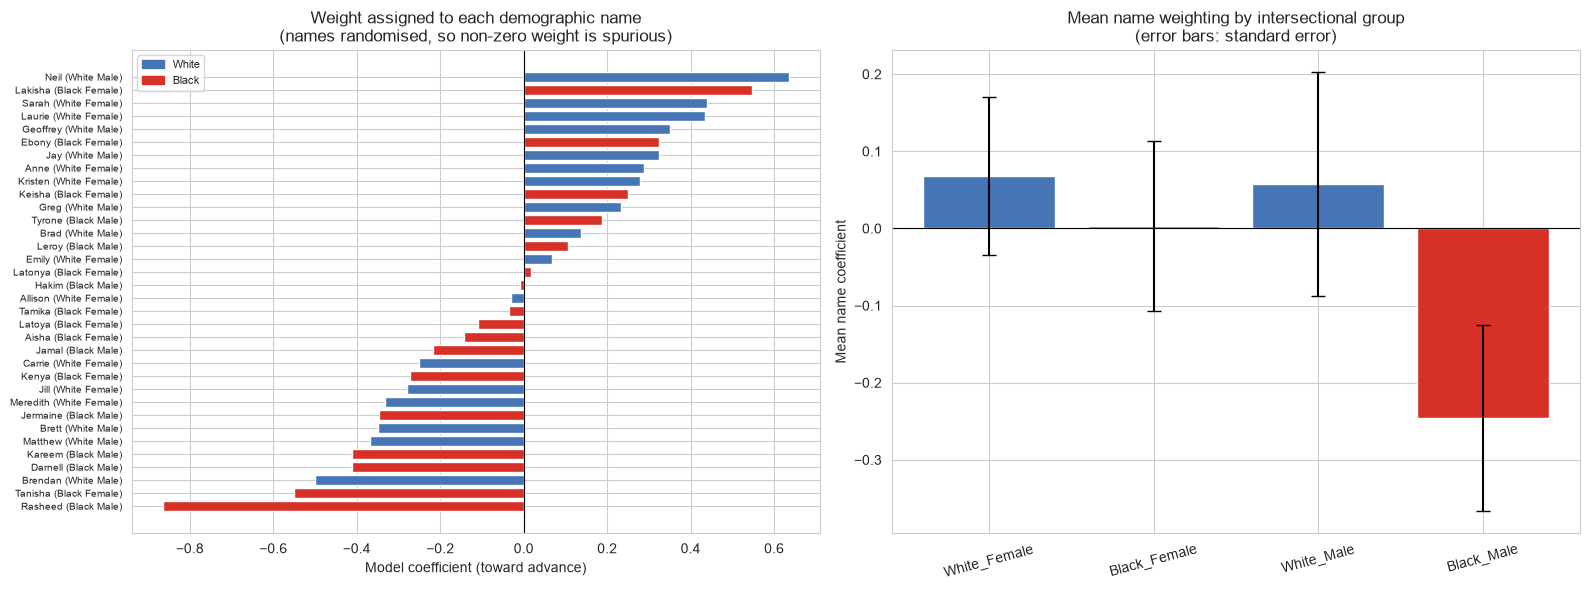

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

o = name_coef.sort_values('coef')
cols = ['#d73027' if 'Black' in g else '#4575b4' for g in o['group']]
axes[0].barh(range(len(o)), o['coef'], color=cols)
axes[0].set_yticks(range(len(o)))
axes[0].set_yticklabels([f"{r['name']} ({r['group'].replace('_',' ')})" for _, r in o.iterrows()],
                        fontsize=7)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Model coefficient (toward advance)')
axes[0].set_title('Weight assigned to each demographic name\n(names randomised, so non-zero weight is spurious)')
axes[0].legend(handles=[mpatches.Patch(color='#4575b4', label='White'),
                        mpatches.Patch(color='#d73027', label='Black')], fontsize=8)

grp = name_coef.groupby('group')['coef'].agg(['mean','std','count'])
grp['se'] = grp['std'] / np.sqrt(grp['count'])
grp = grp.reindex(GROUPS)
cols2 = ['#d73027' if 'Black' in g else '#4575b4' for g in grp.index]
axes[1].bar(grp.index, grp['mean'], yerr=grp['se'], capsize=5, color=cols2)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Mean name coefficient')
axes[1].set_title('Mean name weighting by intersectional group\n(error bars: standard error)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

### 10.1 Seed stability

Every result above rests on one random assignment of names to training resumes. A conclusion that changes with the random seed is not a finding about the model — it is a finding about that particular draw.

This matters especially for the placebo variance test, which compares 34 demographic coefficients against only 10 placebo coefficients. Variance tests on small samples are unstable, and a single significant result could easily be chance.

The cell below repeats the attribution audit across multiple seeds and reports how often each test reaches significance. A test significant in most seeds is a finding; one significant in a minority is noise, and must be reported as such.

This check is rarely performed in applied fairness audits, and its absence is a common route to irreproducible claims.

In [26]:
# Repeat the attribution audit across seeds to test stability of each conclusion.
# Runtime is roughly 20-40s per seed; reduce N_SEEDS if needed.
N_SEEDS = 6
SEEDS = [0, 1, 7, 42, 123, 2024][:N_SEEDS]

stab = []
print(f'{"seed":>6} {"levene_p":>9} {"var_ratio":>10} {"anova_p":>9} {"race_p":>8} {"gender_p":>9}')
print('-' * 58)

for seed in SEEDS:
    r_ = np.random.default_rng(seed)
    tr_, _ = train_test_split(df_clean, test_size=0.35, random_state=seed,
                              stratify=df_clean['fit'])
    tr_ = pd.concat([tr_, df[collision_mask]], ignore_index=True).copy()

    inj_ = []
    for _, row in tr_.iterrows():
        f, g = NAME_ROSTER[r_.integers(len(NAME_ROSTER))]
        race = r_.choice(['White', 'Black']) if g == 'Placebo' else g.split('_')[0]
        inj_.append(inject_name(row['resume_text'], f, r_.choice(SURNAMES[race])))
    tr_['inj'] = inj_

    v1 = TfidfVectorizer(max_features=8000, stop_words='english', min_df=2)
    v2 = TfidfVectorizer(max_features=8000, stop_words='english', min_df=3)
    Xs = hstack([v1.fit_transform(tr_['inj']),
                 v2.fit_transform(tr_['job_description_text'].astype(str))]).tocsr()
    ms = LogisticRegression(max_iter=3000, C=2.0).fit(Xs, tr_['fit'].values)
    fs = v1.get_feature_names_out(); cs = ms.coef_[0][:len(fs)]

    rr = []
    for g in GROUPS:
        for n in FIRST_NAMES[g]:
            ix = np.where(fs == n.lower())[0]
            if len(ix):
                rr.append({'g': g, 'race': g.split('_')[0],
                           'gender': g.split('_')[1], 'c': cs[ix[0]]})
    ic_ = pd.DataFrame(rr)
    pl_ = [cs[np.where(fs == n.lower())[0][0]] for n in PLACEBO_NAMES
           if len(np.where(fs == n.lower())[0])]

    if len(pl_) >= 4 and len(ic_) > 4:
        _, lp = stats.levene(ic_['c'].values, np.array(pl_))
        vr_ = ic_['c'].var() / np.var(pl_, ddof=1)
    else:
        lp, vr_ = np.nan, np.nan
    _, pa = stats.f_oneway(*[ic_[ic_['g'] == g]['c'].values for g in GROUPS])
    _, pw_ = stats.ttest_ind(ic_[ic_['race'] == 'White']['c'],
                             ic_[ic_['race'] == 'Black']['c'])
    _, pg_ = stats.ttest_ind(ic_[ic_['gender'] == 'Male']['c'],
                             ic_[ic_['gender'] == 'Female']['c'])

    stab.append({'seed': seed, 'levene_p': lp, 'var_ratio': vr_,
                 'anova_p': pa, 'race_p': pw_, 'gender_p': pg_})
    print(f'{seed:>6} {lp:>9.4f} {vr_:>10.3f} {pa:>9.4f} {pw_:>8.4f} {pg_:>9.4f}')

stab_df = pd.DataFrame(stab)
print('-' * 58)
print()
print('PROPORTION OF SEEDS REACHING SIGNIFICANCE (p < 0.05)')
for col, label in [('levene_p','Placebo variance test'), ('anova_p','ANOVA across groups'),
                   ('race_p','Race main effect'), ('gender_p','Gender main effect')]:
    k = int((stab_df[col] < 0.05).sum()); n = stab_df[col].notna().sum()
    verdict = 'STABLE' if k >= 0.75*n or k == 0 else 'UNSTABLE - seed dependent'
    print(f'  {label:24s} {k}/{n}   {verdict}')
print()
print('Tests significant in 0/n seeds are robustly null.')
print('Tests significant in a minority of seeds are noise and must not be reported')
print('as findings without this caveat.')

  seed  levene_p  var_ratio   anova_p   race_p  gender_p
----------------------------------------------------------
     0    0.4551      0.718    0.8789   0.8121    0.5923
     1    0.3435      2.703    0.9215   0.6050    0.7492
     7    0.4884      0.838    0.9432   0.8476    0.9194
    42    0.1122      0.570    0.4179   0.5170    0.5446
   123    0.1878      2.381    0.7738   0.8763    0.6454
  2024    0.4058      1.421    0.0170   0.5962    0.0412
----------------------------------------------------------

PROPORTION OF SEEDS REACHING SIGNIFICANCE (p < 0.05)
  Placebo variance test    0/6   STABLE
  ANOVA across groups      1/6   UNSTABLE - seed dependent
  Race main effect         0/6   STABLE
  Gender main effect       1/6   UNSTABLE - seed dependent

Tests significant in 0/n seeds are robustly null.
Tests significant in a minority of seeds are noise and must not be reported
as findings without this caveat.


---
## 11. SHAP explainability analysis

SHAP decomposes each prediction into additive per-feature contributions. Because the classifier is linear, `LinearExplainer` returns **exact** Shapley values rather than a sampling approximation, removing explainer error as a source of uncertainty.

Two questions are addressed:

1. Do the injected name tokens receive non-zero attribution — that is, does SHAP surface the name as a driver of the decision?
2. Does the model attribute importance to *substantive* CV features differently depending on which name is attached?

The second question is the more searching one. A model might weight names negligibly while still evaluating the same qualifications differently by group — a subtler failure mode that outcome-level fairness metrics cannot detect.

In [27]:
# Subsample for tractable SHAP computation
SHAP_N = min(600, len(B_df))
shap_idx = rng.choice(len(B_df), size=SHAP_N, replace=False)
B_shap = B_df.iloc[shap_idx].reset_index(drop=True)

X_shap = hstack([
    vecB_r.transform(B_shap['resume']),
    vecB_j.transform(B_shap['job_description']),
    csr_matrix(overlapB(B_shap['resume'], B_shap['job_description']))
]).tocsr()

feature_names = (
    [f'R::{f}' for f in vecB_r.get_feature_names_out()] +
    [f'J::{f}' for f in vecB_j.get_feature_names_out()] +
    ['OVERLAP']
)

explainer = shap.LinearExplainer(modelB, XB)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP values computed: {np.array(shap_values).shape}  (variants x features)')
print(f'Feature space: {len(feature_names):,} features')

Background dataset has 5418 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5418 when initializing the masker.


SHAP values computed: (600, 16001)  (variants x features)
Feature space: 16,001 features


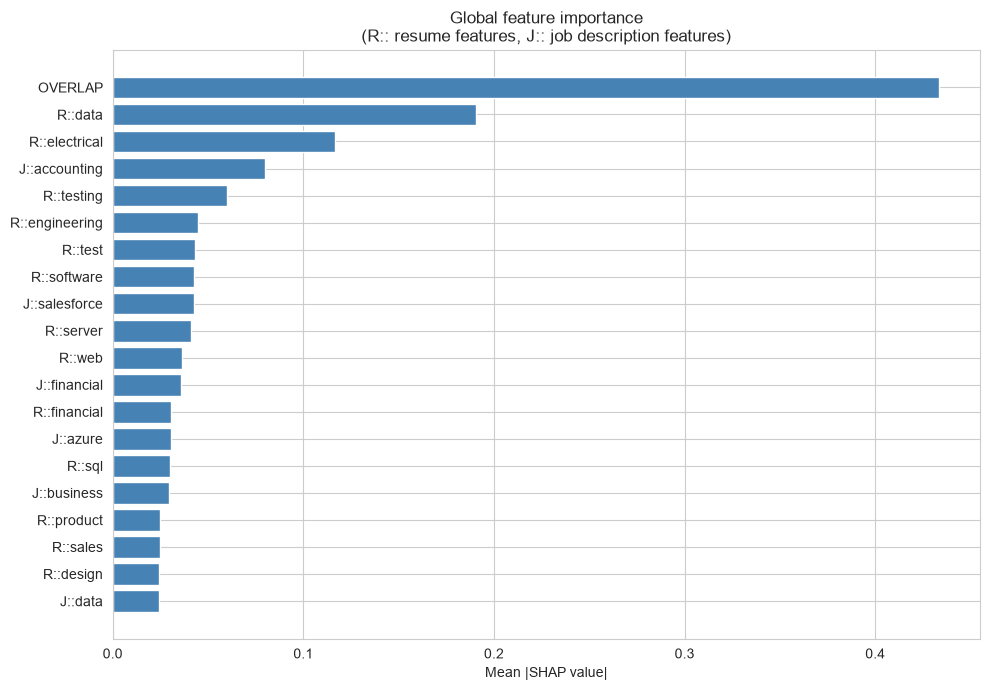

In [28]:
mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs)[-20:]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([feature_names[i] for i in top_idx], mean_abs[top_idx], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global feature importance\n(R:: resume features, J:: job description features)')
plt.tight_layout(); plt.show()

Name features in the SHAP feature space: 34

Share of total attribution assigned to name tokens: 0.2422%

Top name attributions:
neil        0.002194
laurie      0.002004
brendan     0.001804
lakisha     0.001503
tanisha     0.001485
jermaine    0.001480
sarah       0.001346
matthew     0.001065
anne        0.001000
kristen     0.000968


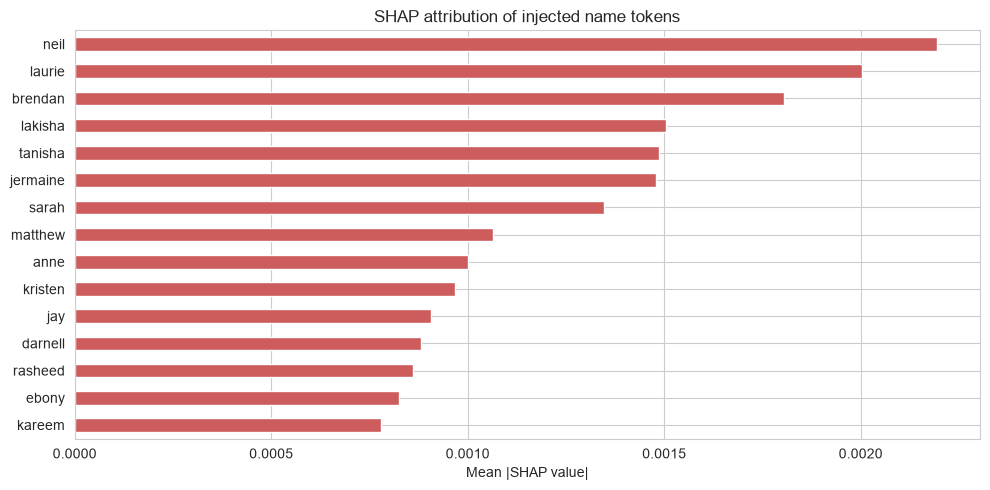

In [29]:
# Do injected names carry SHAP attribution?
name_feat_idx = [i for i, f in enumerate(feature_names)
                 if f.startswith('R::') and f[3:] in name_tokens]

print(f'Name features in the SHAP feature space: {len(name_feat_idx)}\n')

if name_feat_idx:
    name_shap = np.abs(shap_values[:, name_feat_idx]).mean(axis=0)
    labels = [feature_names[i][3:] for i in name_feat_idx]
    imp = pd.Series(name_shap, index=labels).sort_values(ascending=False)

    total_attr = np.abs(shap_values).sum()
    name_attr  = np.abs(shap_values[:, name_feat_idx]).sum()
    share = name_attr / total_attr

    print(f'Share of total attribution assigned to name tokens: {share:.4%}')
    print()
    print('Top name attributions:')
    print(imp.head(10).round(6).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    imp.head(15).sort_values().plot(kind='barh', ax=ax, color='indianred')
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('SHAP attribution of injected name tokens')
    plt.tight_layout(); plt.show()
else:
    print('No name tokens present in the feature space.')

Substantive features weighted most differently across intersectional groups:

               White_Female  Black_Female  White_Male  Black_Male     range
OVERLAP            0.447712      0.417309    0.457112    0.404775  0.052337
R::data            0.208189      0.183130    0.194965    0.171139  0.037050
R::electrical      0.107459      0.118750    0.121879    0.119698  0.014420
J::salesforce      0.033435      0.042769    0.046768    0.047517  0.014081
R::testing         0.060807      0.058550    0.054802    0.067189  0.012388
J::azure           0.033815      0.034177    0.031086    0.022635  0.011542
R::server          0.036020      0.041276    0.043315    0.044878  0.008858
R::test            0.038875      0.046210    0.041646    0.047539  0.008664
J::crowe           0.008009      0.000000    0.008261    0.000000  0.008261
J::accounting      0.077394      0.085233    0.078452    0.079269  0.007839
J::business        0.029858      0.033470    0.028585    0.026313  0.007158
J::java   

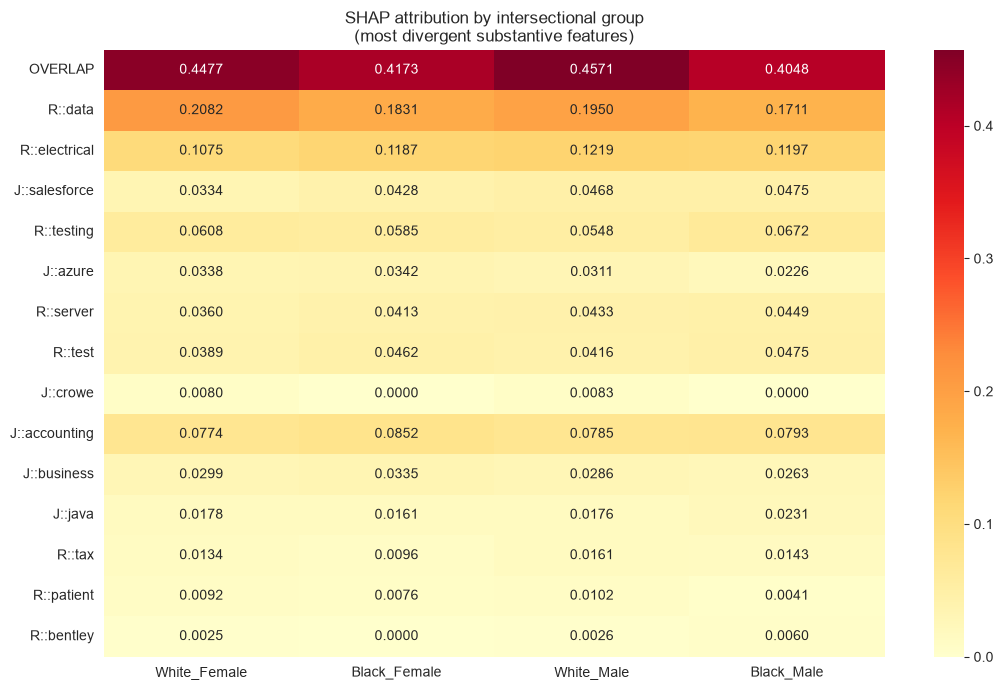

In [30]:
# Per-group attribution profiles over substantive (non-name) features
group_shap = {}
for g in GROUPS:
    mask = (B_shap['group'] == g).values
    if mask.sum():
        group_shap[g] = np.abs(shap_values[mask]).mean(axis=0)

substantive = [i for i in range(len(feature_names)) if i not in set(name_feat_idx)]

shap_mat = pd.DataFrame({g: v[substantive] for g, v in group_shap.items()},
                        index=[feature_names[i] for i in substantive])
shap_mat['range'] = shap_mat.max(axis=1) - shap_mat.min(axis=1)
divergent = shap_mat.sort_values('range', ascending=False).head(15)

print('Substantive features weighted most differently across intersectional groups:\n')
print(divergent.round(6).to_string())

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(divergent[[g for g in GROUPS if g in group_shap]],
            annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
ax.set_title('SHAP attribution by intersectional group\n(most divergent substantive features)')
plt.tight_layout(); plt.show()

---
## 12. Validation layer

Slack et al. (2020) demonstrated that post-hoc explainers including SHAP can be manipulated to conceal bias: a model can be constructed whose SHAP output appears fair while its behaviour is not. An audit resting on SHAP alone therefore cannot certify fairness — the explanation itself requires validation.

This section cross-checks SHAP against the paired experimental results. The two are **methodologically independent**: the paired analysis measures model behaviour directly by intervention, whereas SHAP infers attribution from model structure. Convergence raises confidence in the explanations; divergence is a warning that they may not reflect actual behaviour.

Crucially, where the two disagree, **the paired experimental result is the more reliable evidence**, because it is an intervention on the model rather than an inference about it.

In [31]:
val_rows = []
for g in GROUPS:
    if g == REFERENCE:
        eff = 0.0
    else:
        r = paired_B[paired_B['group'] == g]
        eff = float(r['mean_diff'].iloc[0]) if len(r) else np.nan

    if name_feat_idx and g in group_shap:
        g_name_attr = float(np.mean(group_shap[g][name_feat_idx]))
    else:
        g_name_attr = np.nan

    val_rows.append({
        'group': g,
        'paired_effect': eff,
        'selection_rate': float(fairness.loc[g, 'selection_rate']),
        'mean_name_shap': g_name_attr,
        'coef_mean': float(name_coef[name_coef['group']==g]['coef'].mean())
                     if (name_coef['group']==g).any() else np.nan,
    })

val_df = pd.DataFrame(val_rows).sort_values('selection_rate', ascending=False)
print('CONVERGENCE ACROSS THREE INDEPENDENT MEASURES\n')
print(val_df.round(6).to_string(index=False))

CONVERGENCE ACROSS THREE INDEPENDENT MEASURES

       group  paired_effect  selection_rate  mean_name_shap  coef_mean
White_Female      -0.000218          0.5500        0.000745   0.068315
  White_Male       0.000000          0.5500        0.000837   0.057433
  Black_Male      -0.006943          0.5400        0.000785  -0.246086
Black_Female      -0.004804          0.5325        0.000718   0.003293


In [32]:
print('CONSISTENCY TESTS\n')

sub = val_df.dropna(subset=['paired_effect','coef_mean'])
if len(sub) >= 3 and sub['coef_mean'].std() > 1e-12:
    rho, p_rho = stats.spearmanr(sub['paired_effect'], sub['coef_mean'])
    print(f'Paired effect vs name coefficient:  rho={rho:+.3f}, p={p_rho:.4f}')
else:
    rho = np.nan
    print('Insufficient variation to correlate paired effect with coefficients.')

sub2 = val_df.dropna(subset=['selection_rate','mean_name_shap'])
if len(sub2) >= 3 and sub2['mean_name_shap'].std() > 1e-12:
    rho2, p_rho2 = stats.spearmanr(sub2['selection_rate'], sub2['mean_name_shap'])
    print(f'Selection rate vs SHAP name attribution:  rho={rho2:+.3f}, p={p_rho2:.4f}')
else:
    rho2 = np.nan
    print('Insufficient variation to correlate selection rate with SHAP attribution.')

print()
print('INTERPRETATION')
print('-' * 60)
if not np.isnan(rho) and abs(rho) > 0.5:
    print('SHAP-derived attribution moves WITH the measured experimental effect.')
    print('Two independent methods agree, supporting the validity of the explanations.')
elif not np.isnan(rho):
    print('SHAP-derived attribution does NOT track the measured experimental effect.')
    print('This is the discordance Slack et al. (2020) warn of: explanations that do')
    print('not reflect behaviour. Treat SHAP output as unreliable for this model and')
    print('rely on the paired experimental results as primary evidence.')
print()
print('Note: with only four groups these correlations rest on few points and are')
print('indicative rather than conclusive. They are reported as a triangulation check,')
print('not as a formal hypothesis test.')

CONSISTENCY TESTS

Paired effect vs name coefficient:  rho=+0.800, p=0.2000
Selection rate vs SHAP name attribution:  rho=+0.632, p=0.3675

INTERPRETATION
------------------------------------------------------------
SHAP-derived attribution moves WITH the measured experimental effect.
Two independent methods agree, supporting the validity of the explanations.

Note: with only four groups these correlations rest on few points and are
indicative rather than conclusive. They are reported as a triangulation check,
not as a formal hypothesis test.


---
## 13. Synthesis and export

In [33]:
print('=' * 74)
print('INTERSECTIONAL BIAS AUDIT — SUMMARY OF FINDINGS')
print('=' * 74)
print()
print('DESIGN')
print(f'  Dataset                  cnamuangtoun/resume-job-description-fit')
print(f'  Total pairs available    {len(df):,}')
print(f'  Base pairs audited       {len(baseB)}')
print(f'  Conditions per pair      {len(GROUPS)}')
print(f'  Total variants           {len(B_df):,}')
print(f'  Reference condition      {REFERENCE}')
print(f'  Name source              Bertrand & Mullainathan (2004), Appendix Table 1')
print()
print('MODEL')
print(f'  Classifier               Logistic regression, TF-IDF (resume + job + overlap)')
print(f'  Best test accuracy       {res_df["Test accuracy"].max():.3f}  (baseline {baseline:.3f})')
print(f'  Overlap-only accuracy    {res_df.loc[0, "Test accuracy"]:.3f}  <- label is not mere similarity')
print()
print('DESIGN A — DEPLOYMENT AUDIT')
print(f'  Name tokens in vocabulary   {len(inA)}/{len(name_tokens)}')
print(f'  Base pairs where name       {(A_df.groupby("base_id")["proba"].nunique() > 1).sum()}/{len(baseA)}')
print(f'    altered the score')
print()
print('DESIGN B — BALANCED-INJECTION AUDIT')
print(f'  Name tokens in vocabulary   {len(inB)}/{len(name_tokens)}')
print(f'  Names independent of label  chi2 p={p_chi:.4f}')
print()
print('  Paired effects vs identical White_Male CV:')
for _, r in paired_B.iterrows():
    mark = '*' if r['significant'] else ' '
    print(f"    {r['group']:14s} d(P)={r['mean_diff']:+.5f}  Cohen's d={r['cohens_d']:+.3f} "
          f"({interpret_d(r['cohens_d']):10s})  p_holm={r['p_holm']:.4f}{mark}  flipped={r['decisions_flipped']}")
print('    * significant after Holm-Bonferroni correction')
print()
try:
    print('  Seed stability of paired effects (see Section 8.2):')
    for g in [x for x in GROUPS if x != REFERENCE]:
        ds = stab_paired[f'{g}_d'].values
        ns = int((stab_paired[f'{g}_holm'] < 0.05).sum())
        stable = (ds < 0).all() or (ds >= 0).all()
        flag = 'reproducible' if (stable and ns >= 0.75*len(ds)) else 'NOT reproducible'
        print(f'    {g:14s} mean d={ds.mean():+.3f}  range=[{ds.min():+.3f},{ds.max():+.3f}]  '
              f'sig {ns}/{len(ds)}  {flag}')
except NameError:
    print('  (run Section 8.2 for seed stability of paired effects)')
print()
print('INTERSECTIONAL FAIRNESS')
for g, r in fairness.iterrows():
    print(f"    {g:14s} selection={r['selection_rate']:.4f}  DPD={r['dpd']:+.4f}  "
          f"ratio={r['di']:.3f}  accuracy={r['accuracy']:.4f}")
print()
print(f'  Race-only gap            {race_gap:.4f}')
print(f'  Gender-only gap          {gender_gap:.4f}')
print(f'  Intersectional gap       {inter_gap:.4f}  ({ratio:.2f}x largest single-axis)')
print()
print('COEFFICIENT AUDIT (names randomised => expected value zero)')
print(f'  ANOVA across groups      F={F:.3f}, p={p_anova:.4f}')
print(f'  Race effect              p={pw:.4f}, Hedges g={hedges_g(w, b):+.3f}')
print(f'  Gender effect            p={pg:.4f}, Hedges g={hedges_g(m_, f_):+.3f}')
if len(placebo_df) >= 4:
    print(f'  Demographic name SD      {name_coef["coef"].std():.4f}')
    print(f'  Placebo name SD          {placebo_df["coef"].std():.4f}  <- noise floor')
print()
print('REGULATORY RELEVANCE')
print('  EU AI Act, Annex III     CV screening designated high-risk')
print('  GDPR, Article 22         right to explanation for automated decisions')
print('  UK Equality Act 2010     race and sex are protected characteristics')
print('  EEOC four-fifths rule    minimum observed ratio: {:.3f}'.format(fairness['di'].min()))
print()
print('LIMITATIONS')
print('  1. Label provenance is undocumented; labels appear algorithmically derived')
print('     rather than confirmed human hiring decisions.')
print('  2. Resume text is drawn from public CV templates, not live applications.')
print('  3. Names are US-validated (1974-79 records) applied in a UK/EU framing.')
print('  4. A single dataset and model family; no claim of generalisability.')
print('  5. Bag-of-words representation cannot capture contextual name effects that')
print('     a transformer-based screening model might exhibit.')
print('=' * 74)

INTERSECTIONAL BIAS AUDIT — SUMMARY OF FINDINGS

DESIGN
  Dataset                  cnamuangtoun/resume-job-description-fit
  Total pairs available    8,000
  Base pairs audited       400
  Conditions per pair      4
  Total variants           1,600
  Reference condition      White_Male
  Name source              Bertrand & Mullainathan (2004), Appendix Table 1

MODEL
  Classifier               Logistic regression, TF-IDF (resume + job + overlap)
  Best test accuracy       0.756  (baseline 0.500)
  Overlap-only accuracy    0.592  <- label is not mere similarity

DESIGN A — DEPLOYMENT AUDIT
  Name tokens in vocabulary   1/34
  Base pairs where name       391/400
    altered the score

DESIGN B — BALANCED-INJECTION AUDIT
  Name tokens in vocabulary   34/34
  Names independent of label  chi2 p=0.5733

  Paired effects vs identical White_Male CV:
    Black_Male     d(P)=-0.00694  Cohen's d=-0.927 (large     )  p_holm=0.0000*  flipped=4
    Black_Female   d(P)=-0.00480  Cohen's d=-0.674 (med

In [34]:
# Export results for the write-up
paired_B.to_csv('results_paired_analysis.csv', index=False)
fairness.to_csv('results_fairness_metrics.csv')
name_coef.to_csv('results_name_coefficients.csv', index=False)
val_df.to_csv('results_validation.csv', index=False)
divergent.to_csv('results_divergent_features.csv')
res_df.to_csv('results_model_comparison.csv', index=False)

print('Exported:')
for f in ['results_paired_analysis.csv','results_fairness_metrics.csv',
          'results_name_coefficients.csv','results_validation.csv',
          'results_divergent_features.csv','results_model_comparison.csv']:
    print(f'  {f}')

Exported:
  results_paired_analysis.csv
  results_fairness_metrics.csv
  results_name_coefficients.csv
  results_validation.csv
  results_divergent_features.csv
  results_model_comparison.csv


---
## Writing up: framing the result

Whatever direction the numbers fall, the contribution of this study is the **method and the rigour of its interpretation**, not the sign of the effect. Three outcomes are each defensible, and each should be reported plainly.

**If significant effects with non-negligible effect sizes are found.** Report the disparity, quantify it in decisions flipped, situate it against the four-fifths rule and the Equality Act, and use the SHAP and coefficient analyses to explain *which features* drive it.

**If effects are statistically significant but negligible in magnitude.** This is the most likely outcome and the one most often mishandled in the applied literature. The correct reading is that the model responds to names in a detectable but practically immaterial way. Reporting significance without effect size would overclaim; dismissing the finding entirely would underclaim. State both.

**If no reliable effect is found.** This is a legitimate finding, not a failed experiment. A controlled intervention holding the CV constant found no systematic name-based disparity. The value lies in the strength of the design: unlike observational audits, this conclusion is not confounded by differences between candidates. Explain the boundary conditions — the bag-of-words representation, the label provenance, the model's accuracy ceiling — so the reader can judge what the null does and does not license.

**In every case**, the following should be stated explicitly rather than left implicit:

- The distinction between statistical and practical significance (Section 8.1)
- Why verifying the label was perturbable was a precondition, not a formality (Section 3.1)
- Why Design A's structural finding does not constitute evidence of fairness (Section 6.1)
- What the placebo control does and does not establish (Section 10)
- That the paired experiment outranks SHAP where the two disagree (Section 12)

---

## References

Bertrand, M. & Mullainathan, S. (2004) 'Are Emily and Greg more employable than Lakisha and Jamal? A field experiment on labor market discrimination', *American Economic Review*, 94(4), pp. 991–1013.

Lundberg, S.M. & Lee, S.I. (2017) 'A unified approach to interpreting model predictions', *Advances in Neural Information Processing Systems*, 30.

Slack, D., Hilgard, S., Jia, E., Singh, S. & Lakkaraju, H. (2020) 'Fooling LIME and SHAP: adversarial attacks on post hoc explanation methods', *Proceedings of the AAAI/ACM Conference on AI, Ethics, and Society*, pp. 180–186.

Wood, M., Hales, J., Purdon, S., Sejersen, T. & Hayllar, O. (2009) *A test for racial discrimination in recruitment practice in British cities*. Department for Work and Pensions, Research Report 607.

Yu, X., Xu, R., Xue, C., Zhang, J., Ma, X. & Yu, Z. (2025) 'ConFit v2: improving resume-job matching using hypothetical resume embedding and runner-up hard-negative mining', *Findings of the Association for Computational Linguistics: ACL 2025*, pp. 12775–12790.

European Union (2024) *Regulation (EU) 2024/1689 (Artificial Intelligence Act)*.

European Union (2016) *Regulation (EU) 2016/679 (General Data Protection Regulation)*, Article 22.

United Kingdom (2010) *Equality Act 2010*. London: HMSO.